# Unstretch and Regularize Matrix to Scale

In [1]:
# Imports
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import copy

# I/O Allocation

In [12]:
# Path Variables:
repo_path = "/Users/caoze/Documents/GitHub/Photon-Transport-Simulation/"     # Replace with repository path
export_address = "data/processed/"
access_address = "data/extracted_ri/"         

# Helpers:
def output_address(subfolder="data/", repository=repo_path):
    out_path = f"{repository}{subfolder}"
    return out_path

def modified_output_address(file_name):
    name_part = file_name.split("_")[0]
    new_name = f"{name_part}_processed.mat"
    return new_name

In [3]:
# Accessing
file_name = "test_extracted.mat"
access_path = f"{repo_path}{access_address}{file_name}"
print("Accessing: " + access_path)

# Open file:
print("Accessing")
content = sp.io.loadmat(access_path)
print(content.keys())

Accessing: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/extracted_ri/test_extracted.mat
Accessing
dict_keys(['__header__', '__version__', '__globals__', 'masked_ri'])


# Load in and Modified Matrix to Desired Scale

(212, 376)


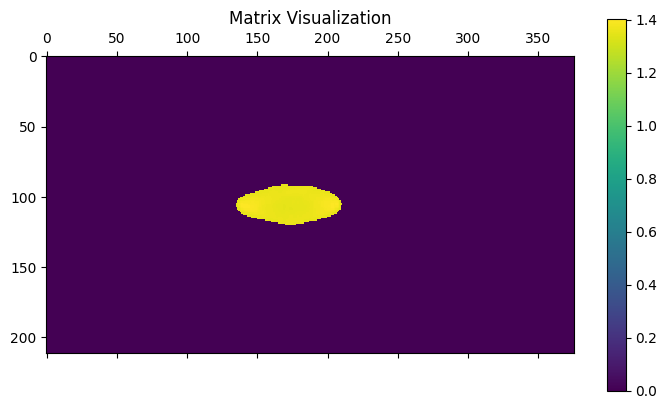

In [4]:
# Retrieve Matrix
extract = content['masked_ri']
pix_num = [extract.shape[1], extract.shape[0]]
print(extract.shape)

# Verify
plt.matshow(extract) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Matrix Visualization")
plt.show() 

Unstretch The x distortion to 5 pixels per um and stretch y to 5 pixel per um, and truncate empty area centered out of the center of the cell, create a on scale square frame of 5 pixels per micron.

Resolutions: 10.531799873394322 pixels per um, 1.0 pixels per um
Target pixels: 179 (x), 1060 (y)
Zoom factors: x = 0.476, y = 5.000
Original shape: (212, 376)
Resampled shape: (1060, 179)


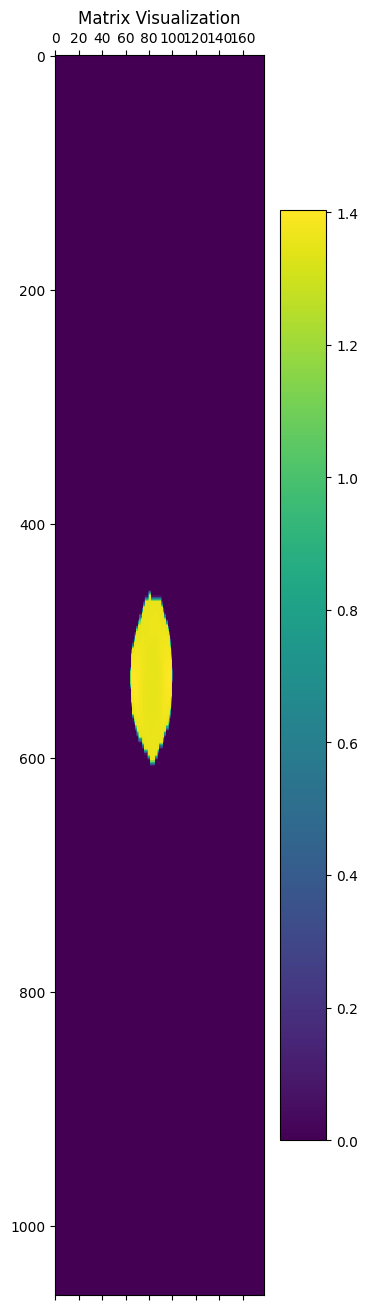

In [5]:
from scipy.ndimage import zoom
# Scaling
unit = "um"
phys_length = 35.7014
phys_height = 212
x_res = pix_num[0]/phys_length      #pix per micron
y_res = pix_num[1]/phys_height
print(f"Resolutions: {x_res} pixels per um, {y_res} pixels per um")

# Target Resolution
target_res = 5 # Pixels per micron

nx = int(round(phys_length * target_res))
ny = int(round(phys_height * target_res))
print(f"Target pixels: {nx} (x), {ny} (y)")

# Compute Zoom Facter:
zoom_x = nx / pix_num[0]
zoom_y = ny / pix_num[1]
print(f"Zoom factors: x = {zoom_x:.3f}, y = {zoom_y:.3f}")

# Resample: 
resampled = zoom(extract, (zoom_y, zoom_x), order=1)  # linear interpolation
resampled = np.asarray(resampled)  # ensure ndarray-compatible type for matplotlib

print("Original shape:", extract.shape)
print("Resampled shape:", resampled.shape)

# Verify
plt.matshow(resampled)
plt.colorbar() # Creates a colorbar for the plot
plt.title("Matrix Visualization")
plt.show() 

Truncate Empty Area with the cell at center.

In [6]:
# Finds High and Low Cutoff Of Cell
def find_cutoff(array, cut):
    """Find high or low cutoff of the cell along rows (y-axis)"""
    ny, nx = array.shape
    cell_level = []

    if cut == 'low':
        # from top to bottom
        for i in range(ny):
            if np.sum(array[i, :]) > 0:
                # check for 3 consecutive rows
                if i >= 2 and np.sum(array[i-1, :]) > 0 and np.sum(array[i-2, :]) > 0:
                    cell_level.append(i)
        return max(cell_level)  # lowest row where cell is present

    elif cut == 'high':
        # from bottom to top
        for i in range(ny):
            if np.sum(array[ny - 1 - i, :]) > 0:
                # check previous two rows from bottom
                if i >= 2 and np.sum(array[ny - i, :]) > 0 and np.sum(array[ny - i + 1, :]) > 0:
                    cell_level.append(ny - 1 - i)
        return min(cell_level)  # highest row where cell is present

    else:
        raise ValueError("cut must be 'low' or 'high'")

# Define Cell Boundary Height-wise
low_cut = find_cutoff(resampled, 'low')
high_cut = find_cutoff(resampled, 'high')
cell_cent = low_cut + (high_cut - low_cut)/2
print(f"Upper and lower bounds of cell: {low_cut}, {high_cut}")
print(f"Center height of cell = {cell_cent}")

Upper and lower bounds of cell: 607, 457
Center height of cell = 532.0


Resampling from height 443 to 622
(179, 179)


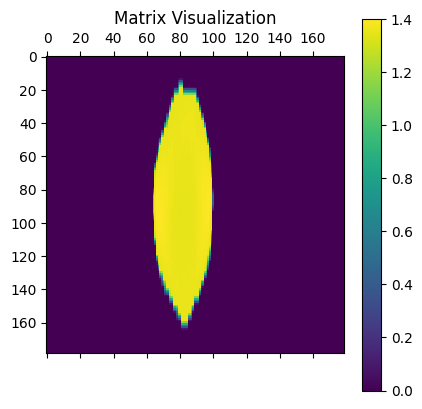

In [10]:
# Truncate Operation
# Compute start/end indices for slicing
resampling_start = int(cell_cent - nx // 2)
resampling_end = resampling_start + nx
print(f"Resampling from height {resampling_start} to {resampling_end}")

# Slice and regularize
regularized = np.zeros((nx,nx))
regularized = resampled[resampling_start:resampling_end, 0:nx]
regularized = np.asarray(regularized)
print(regularized.shape)

# Verify
plt.matshow(regularized)
plt.colorbar() # Creates a colorbar for the plot
plt.title("Matrix Visualization")
plt.show() 

# Save Output

In [13]:
# Save the extracted geometry as a .mat file:
# Export address and name:
output_path = output_address(export_address, repo_path)
output_name = modified_output_address(file_name=file_name)

# Save
try:
    sp.io.savemat(f"{output_path}{output_name}", {"masked_ri": regularized})
    print(f"Extracted RI matrix saved successfully at {output_path}{output_name}!")
except Exception as e:
    print(f"Error saving extracted RI matrix: {e}")
    raise

Extracted RI matrix saved successfully at /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/processed/test_processed.mat!
